# Topic Modeling — TF-IDF + KMeans (с препроцессингом)
**Le Wagon:** Machine Learning → NLP / TF-IDF (2.3) + KMeans Clustering (2.2)

**Что было не так раньше:**
- Не было стоп-слов → "здравствуйте", "добрый", "на" доминировали
- Не было лемматизации → "уборку", "уборка", "уборки" = 3 разных слова
- Число тем (k) выбиралось вслепую

**Что делаем:**
1. Лемматизация (pymorphy3) + стоп-слова + чистка
2. TF-IDF + KMeans для k = 5..20
3. Silhouette score + штраф за мусорные кластеры
4. GPT-4o-mini оценивает когерентность тем и выбирает лучший k
5. Сохраняем результат

In [1]:
# Установка (раскомментируй если нужно)
# !pip install pymorphy3 pyarrow openai

In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import pymorphy3
import re
import json
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────────
PARQUET_PATH = "threads_sample_classified.parquet"  # ← путь к файлу
K_RANGE = range(5, 21)                              # перебираем k от 5 до 20
CATEGORIES = ["QUESTION", "PROBLEM"]                 # какие категории кластеризуем

# GPT evaluation (опционально — требует API ключ)
USE_GPT_EVAL = True
OPENAI_API_KEY = None  # ← вставь ключ или задай через os.environ["OPENAI_API_KEY"]

## 1. Стоп-слова

Раньше TF-IDF получал сырой текст. Слова вроде "здравствуйте", "добрый день", "пожалуйста" 
появляются в **каждом** треде — по формуле TF-IDF у них должен быть низкий вес, 
но с `min_df=2` и `sublinear_tf=True` они всё равно пролезают.

Решение: явный список стоп-слов = стандартные русские + **отельный чат-шум** 
(приветствия, "спасибо", "ок", "понял").

In [3]:
# ── Русские стоп-слова + шум отельного чата ───────────────────────────────────
STOP_WORDS = set("""
и в во не что он на я с со как а то все она так его но да ты к у же вы за бы по
только ее мне было вот от меня еще нет о ней ему теперь когда даже ну вдруг ли
если уже или ни быть был нибудь раз уж вам вас их бы них она они оно мы ими им
будет будь будьте этот того без может мог бы лишь один себя себе чем чтоб чтобы
ведь другой кто тут там потом наш при где более всех этих после этом два какой
мой свой свою тебя тебе тогда та то ту те до ещё мои мою мое моя моей моего
нас для нее над нам об так из за через очень все сами весь вся всю всего всех
этому этой всей этих того этот тоже каждый каждая каждое какой который
здравствуйте здравствуй привет добрый день вечер утро доброе доброго
пожалуйста спасибо ок хорошо ладно понял понятно сделать
""".split())

print(f"Стоп-слов: {len(STOP_WORDS)}")

Стоп-слов: 150


## 2. Лемматизация (pymorphy3)

Без лемматизации: "уборку", "уборка", "уборки", "уборке" = 4 разных токена.  
С лемматизацией: все → "уборка".

Это критично для коротких чат-сообщений — без лемматизации TF-IDF 
размазывает вес одного понятия по нескольким словоформам, и кластеры разваливаются.

**Le Wagon:** Data Toolkit → Text Preprocessing (lowercase, strip, remove punctuation)

In [4]:
# ── Лемматизатор ──────────────────────────────────────────────────────────────
morph = pymorphy3.MorphAnalyzer()

def preprocess(text: str) -> str:
    """
    Русский отельный чат → чистые леммы.

    1. Убираем разделители тредов (---)
    2. Lowercase
    3. Убираем всё кроме кириллицы
    4. Токенизация → лемматизация → фильтр стоп-слов
    """
    text = text.replace('---', ' ').lower()
    text = re.sub(r'[^а-яё\s]', ' ', text)
    tokens = text.split()
    lemmas = []
    for t in tokens:
        if len(t) < 3:
            continue
        lemma = morph.parse(t)[0].normal_form
        if lemma not in STOP_WORDS and len(lemma) >= 3:
            lemmas.append(lemma)
    return ' '.join(lemmas)

# ── Проверка ──
test_raw = "Здравствуйте! Подскажите, пожалуйста, когда у нас запланирована уборка номера?"
test_clean = preprocess(test_raw)
print(f"RAW:   {test_raw}")
print(f"CLEAN: {test_clean}")

RAW:   Здравствуйте! Подскажите, пожалуйста, когда у нас запланирована уборка номера?
CLEAN: подсказать запланировать уборка номер


In [5]:
# ── Загрузка и препроцессинг ───────────────────────────────────────────────────
df = pd.read_parquet(PARQUET_PATH)
print(f"Всего тредов: {len(df)}")
print(f"Категории:\n{df['category'].value_counts().to_string()}")

# Препроцессим тексты один раз и сохраняем
df['text_clean'] = df['text'].apply(preprocess)

# Пример: до и после
print(f"\n── Пример (PROBLEM) ──")
sample = df[df['category'] == 'PROBLEM'].iloc[0]
print(f"RAW:   {sample['text'][:150]}")
print(f"CLEAN: {sample['text_clean'][:150]}")

Всего тредов: 1114
Категории:
category
PROBLEM     586
QUESTION    432
OTHER        96

── Пример (PROBLEM) ──
RAW:   Добрый день, как обычно из номера сверху регулярный грохот и стук. Очень мешает жить. Хочу попросить Ваших коллег, чтобы они предложили соседям сверху
CLEAN: обычно номер сверху регулярный грохот стук мешать жить хотеть попросить ваш коллега предложить сосед сверху начать уважать человек заранее


## 3. TF-IDF + KMeans: перебор k = 5..20

**Le Wagon:** Machine Learning → Choosing K with silhouette / elbow method (section 2.3)

Для каждого k считаем:
- **Silhouette score** — насколько кластеры "плотные" и далёкие друг от друга (выше = лучше)
- **Max cluster %** — доля самого большого кластера (>35% = вероятно мусорный catchall)
- **Tiny clusters** — сколько кластеров содержат <2% данных (= шум)

In [6]:
def run_clustering(texts_clean, k):
    """TF-IDF + KMeans для данного k. Возвращает метрики + темы."""
    vec = TfidfVectorizer(
        max_features=500,
        ngram_range=(1, 2),  # униграммы + биграммы
        min_df=2,             # слово должно быть хотя бы в 2 документах
        sublinear_tf=True,    # сглаживание TF (Le Wagon → TF-IDF formula)
    )
    X = vec.fit_transform(texts_clean)
    terms = vec.get_feature_names_out()

    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)

    sil = silhouette_score(
        X, labels, metric='cosine',
        sample_size=min(500, len(texts_clean))
    )

    topics = []
    for i, center in enumerate(km.cluster_centers_):
        top_idx = center.argsort()[-5:][::-1]
        top_terms = [terms[j] for j in top_idx]
        cluster_idx = np.where(labels == i)[0]
        size = len(cluster_idx)
        # 3 примера текстов из кластера
        samples = [texts_clean[j][:120] for j in cluster_idx[:3]]
        topics.append({
            'id': i + 1,
            'size': size,
            'top_terms': top_terms,
            'samples': samples,
        })

    max_pct = max(t['size'] for t in topics) / len(texts_clean)
    tiny = sum(1 for t in topics if t['size'] < len(texts_clean) * 0.02)

    return {
        'k': k,
        'silhouette': sil,
        'inertia': km.inertia_,
        'max_cluster_pct': max_pct,
        'tiny_clusters': tiny,
        'topics': topics,
    }

In [7]:
# ── Перебор k для каждой категории ─────────────────────────────────────────────
all_results = {}

for cat in CATEGORIES:
    print(f"\n{'═' * 60}")
    print(f"  {cat}")
    print(f"{'═' * 60}")

    texts_clean = df[df['category'] == cat]['text_clean'].tolist()
    texts_clean = [t for t in texts_clean if len(t.strip()) > 0]
    print(f"  Тредов после очистки: {len(texts_clean)}")

    results_list = []
    for k in K_RANGE:
        r = run_clustering(texts_clean, k)
        results_list.append(r)

        flag = ''
        if r['max_cluster_pct'] > 0.35:
            flag += ' ⚠️ catchall'
        if r['tiny_clusters'] > 0:
            flag += f' ⚠️ {r["tiny_clusters"]} мелких'
        print(f"  k={k:2d}  silhouette={r['silhouette']:.3f}  "
              f"max_cluster={r['max_cluster_pct']:.0%}  "
              f"tiny={r['tiny_clusters']}{flag}")

    all_results[cat] = results_list


════════════════════════════════════════════════════════════
  QUESTION
════════════════════════════════════════════════════════════
  Тредов после очистки: 429
  k= 5  silhouette=0.086  max_cluster=60%  tiny=0 ⚠️ catchall
  k= 6  silhouette=0.086  max_cluster=46%  tiny=0 ⚠️ catchall
  k= 7  silhouette=0.080  max_cluster=49%  tiny=0 ⚠️ catchall
  k= 8  silhouette=0.105  max_cluster=43%  tiny=0 ⚠️ catchall
  k= 9  silhouette=0.114  max_cluster=45%  tiny=0 ⚠️ catchall
  k=10  silhouette=0.111  max_cluster=35%  tiny=0 ⚠️ catchall
  k=11  silhouette=0.114  max_cluster=28%  tiny=0
  k=12  silhouette=0.101  max_cluster=24%  tiny=0
  k=13  silhouette=0.125  max_cluster=18%  tiny=0
  k=14  silhouette=0.120  max_cluster=20%  tiny=0
  k=15  silhouette=0.121  max_cluster=21%  tiny=0
  k=16  silhouette=0.122  max_cluster=18%  tiny=1 ⚠️ 1 мелких
  k=17  silhouette=0.105  max_cluster=25%  tiny=0
  k=18  silhouette=0.111  max_cluster=24%  tiny=1 ⚠️ 1 мелких
  k=19  silhouette=0.125  max_cluster=13% 

## 4. Графики: Silhouette + Elbow

**Le Wagon:** Machine Learning → KMeans → Choosing K (elbow method)

- **Silhouette**: выше = лучше (но для текстовых данных значения обычно низкие, 0.05–0.15 — норма)
- **Inertia (elbow)**: ищем "локоть" — точку после которой падение замедляется

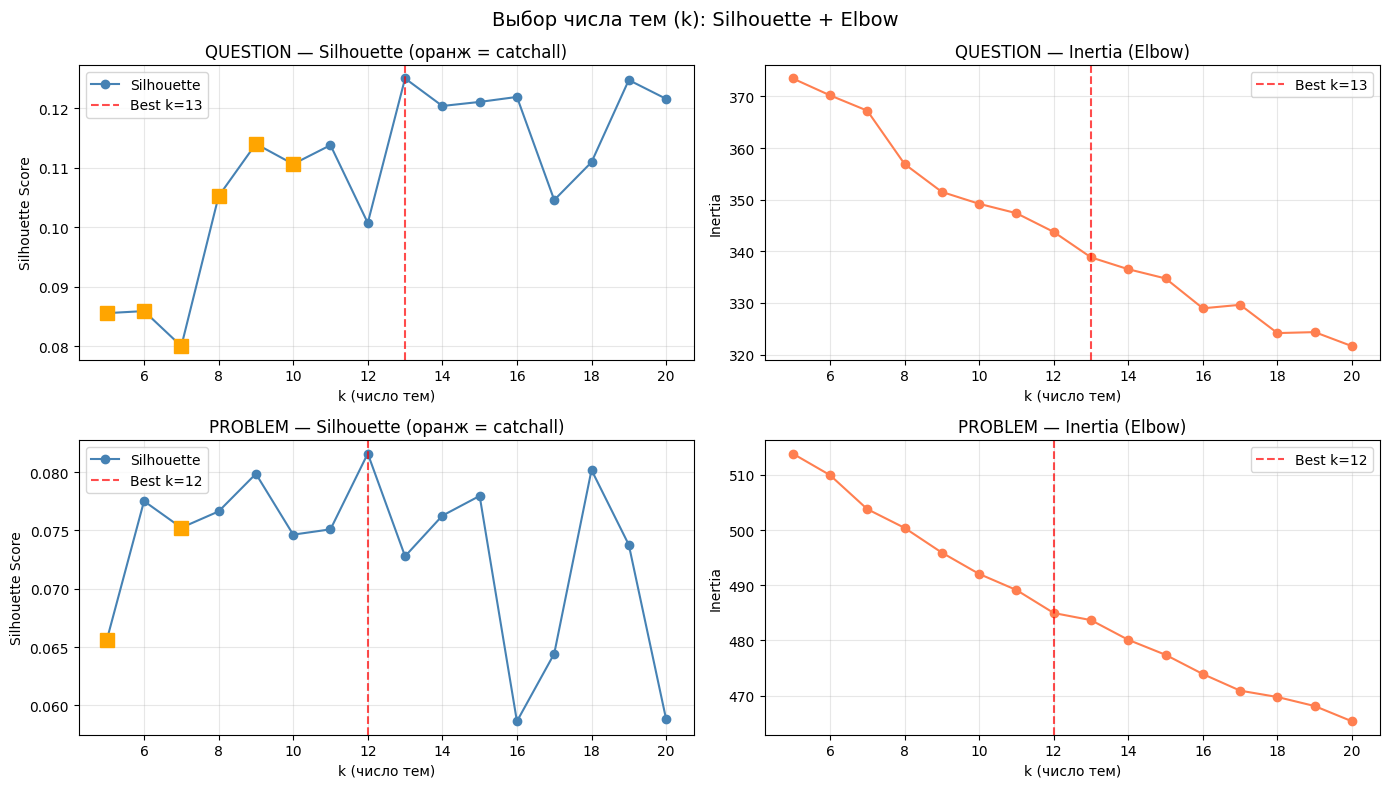


📊 QUESTION: silhouette выбирает k=13 (sil=0.125)

📊 PROBLEM: silhouette выбирает k=12 (sil=0.082)


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Выбор числа тем (k): Silhouette + Elbow', fontsize=14)

for idx, cat in enumerate(CATEGORIES):
    results = all_results[cat]
    ks = [r['k'] for r in results]
    sils = [r['silhouette'] for r in results]
    inertias = [r['inertia'] for r in results]
    max_pcts = [r['max_cluster_pct'] for r in results]

    # Adjusted score (silhouette с штрафом за catchall)
    adj = [s - 0.05 * (p > 0.35) - 0.02 * r['tiny_clusters']
           for s, p, r in zip(sils, max_pcts, results)]
    best_k_sil = ks[np.argmax(adj)]

    # Silhouette plot
    ax = axes[idx, 0]
    ax.plot(ks, sils, 'o-', color='steelblue', label='Silhouette')
    ax.axvline(best_k_sil, color='red', linestyle='--', alpha=0.7,
               label=f'Best k={best_k_sil}')
    # Highlight catchall zones
    for i, (k, p) in enumerate(zip(ks, max_pcts)):
        if p > 0.35:
            ax.plot(k, sils[i], 's', color='orange', markersize=10, zorder=5)
    ax.set_title(f'{cat} — Silhouette (оранж = catchall)')
    ax.set_xlabel('k (число тем)')
    ax.set_ylabel('Silhouette Score')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Elbow plot
    ax = axes[idx, 1]
    ax.plot(ks, inertias, 'o-', color='coral')
    ax.axvline(best_k_sil, color='red', linestyle='--', alpha=0.7,
               label=f'Best k={best_k_sil}')
    ax.set_title(f'{cat} — Inertia (Elbow)')
    ax.set_xlabel('k (число тем)')
    ax.set_ylabel('Inertia')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print silhouette-based pick
for cat in CATEGORIES:
    results = all_results[cat]
    adj = [r['silhouette'] - 0.05 * (r['max_cluster_pct'] > 0.35) - 0.02 * r['tiny_clusters']
           for r in results]
    best = results[np.argmax(adj)]
    print(f"\n📊 {cat}: silhouette выбирает k={best['k']} (sil={best['silhouette']:.3f})")

## 5. GPT-4o-mini оценивает когерентность тем

Silhouette — математическая метрика, но она не понимает **смысл**.
Два кластера про "стиральную машину" и "сушилку" могут иметь хороший silhouette,
но для менеджера отеля это одна тема.

GPT видит все варианты k и оценивает:
- Дублирование тем (одна тема разбита на 2+ кластера)
- Мусорные темы (без ясного смысла)
- Гигантские catchall-кластеры
- Слишком мелкие кластеры

**Стоимость:** ~$0.01-0.02 за один вызов (все k за раз)

In [9]:
def evaluate_with_gpt(results_list, category, api_key=None):
    """
    Отправляем ВСЕ варианты k в GPT-4o-mini одним запросом.
    GPT оценивает каждый k по шкале 1-10 и выбирает лучший.
    """
    import os
    try:
        from openai import OpenAI
    except ImportError:
        print("  ⚠️  pip install openai")
        return None

    key = api_key or OPENAI_API_KEY or os.environ.get("OPENAI_API_KEY")
    if not key:
        print("  ⚠️  Нет OPENAI_API_KEY — пропускаем GPT оценку")
        return None

    client = OpenAI(api_key=key)

    # Формируем компактную сводку всех k
    summary_lines = []
    for r in results_list:
        summary_lines.append(f"\n--- k={r['k']} (silhouette={r['silhouette']:.3f}) ---")
        for t in r['topics']:
            terms_str = ', '.join(t['top_terms'])
            summary_lines.append(f"  Тема {t['id']} ({t['size']} тредов): {terms_str}")
    summary = '\n'.join(summary_lines)

    prompt = f"""Ты — аналитик отельных операций. Ниже — результаты кластеризации
гостевых сообщений (категория: {category}) методом TF-IDF + KMeans с разным числом тем (k).

Слова уже лемматизированы (именительный падеж, инфинитив).

{summary}

ЗАДАЧА:
1. Для каждого k оцени качество тем по шкале 1-10:
   - 10 = каждая тема — четкая операционная категория, нет дублей, нет мусора
   - 1 = темы бессмысленные или все одинаковые

2. Учитывай:
   - Дублирование (одна тема разбита на 2+ кластера = плохо)
   - Мусорные темы (без ясного смысла = плохо)
   - Очень большие кластеры >30% (catchall = плохо)
   - Слишком мелкие кластеры <3% (шум = плохо)

3. Выбери лучший k.

Ответь СТРОГО в JSON:
{{
  "evaluations": [
    {{"k": 5, "score": 7, "issues": "краткое описание проблем"}},
    ...
  ],
  "best_k": 12,
  "best_k_reason": "почему этот k лучший"
}}"""

    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.1,
            max_tokens=2000,
        )
        text = response.choices[0].message.content
        text = re.sub(r'```json\s*', '', text)
        text = re.sub(r'```\s*', '', text)
        return json.loads(text)
    except Exception as e:
        print(f"  ⚠️  GPT ошибка: {e}")
        return None

In [10]:
# ── Запуск GPT оценки ─────────────────────────────────────────────────────────
gpt_results = {}

for cat in CATEGORIES:
    print(f"\n{'═' * 60}")
    print(f"  🤖 GPT оценка: {cat}")
    print(f"{'═' * 60}")

    if USE_GPT_EVAL:
        gpt_res = evaluate_with_gpt(all_results[cat], cat)
    else:
        gpt_res = None

    gpt_results[cat] = gpt_res

    if gpt_res:
        print(f"\n  GPT выбрал: k={gpt_res['best_k']}")
        print(f"  Причина: {gpt_res['best_k_reason']}")
        print(f"\n  Оценки по k:")
        for ev in gpt_res['evaluations']:
            bar = '█' * ev['score'] + '░' * (10 - ev['score'])
            print(f"    k={ev['k']:2d}  [{bar}] {ev['score']}/10  {ev.get('issues', '')}")
    else:
        print("  GPT оценка не выполнена — используем silhouette")


════════════════════════════════════════════════════════════
  🤖 GPT оценка: QUESTION
════════════════════════════════════════════════════════════

  GPT выбрал: k=12
  Причина: k=12 имеет наиболее четкие и разнообразные темы с минимальным количеством пересечений и сбалансированным распределением тредов.

  Оценки по k:
    k= 5  [██████░░░░] 6/10  Тема 2 и Тема 5 имеют пересечения, дублируя запросы на номера. Тема 3 слишком мала.
    k= 6  [███████░░░] 7/10  Тема 5 и Тема 1 имеют пересечения. Тема 4 и Тема 3 слишком малы.
    k= 7  [██████░░░░] 6/10  Тема 1 и Тема 5 дублируют запросы на номера. Тема 6 слишком мала.
    k= 8  [████████░░] 8/10  Темы более четкие, но Тема 4 и Тема 5 имеют пересечения. Тема 1 и Тема 7 слишком малы.
    k= 9  [████████░░] 8/10  Темы более четкие, но Тема 4 и Тема 5 имеют пересечения. Тема 8 слишком мала.
    k=10  [████████░░] 8/10  Темы более четкие, но Тема 4 и Тема 6 имеют пересечения. Тема 7 слишком мала.
    k=11  [█████████░] 9/10  Темы четкие и ра

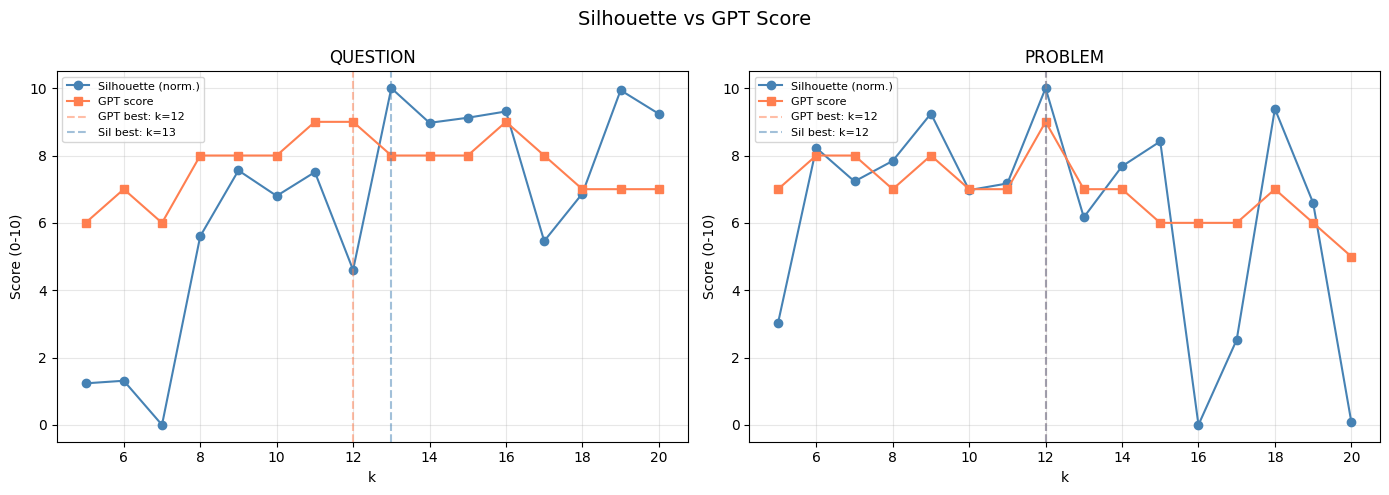

In [11]:
# ── Сравнение: Silhouette vs GPT ───────────────────────────────────────────────
has_gpt = any(gpt_results[cat] is not None for cat in CATEGORIES)

if has_gpt:
    fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(14, 5))
    if len(CATEGORIES) == 1:
        axes = [axes]
    fig.suptitle('Silhouette vs GPT Score', fontsize=14)

    for idx, cat in enumerate(CATEGORIES):
        ax = axes[idx]
        results = all_results[cat]
        ks = [r['k'] for r in results]
        sils = [r['silhouette'] for r in results]

        # Normalize silhouette to 0-10 scale for comparison
        sil_min, sil_max = min(sils), max(sils)
        if sil_max > sil_min:
            sils_norm = [10 * (s - sil_min) / (sil_max - sil_min) for s in sils]
        else:
            sils_norm = [5] * len(sils)

        ax.plot(ks, sils_norm, 'o-', color='steelblue', label='Silhouette (norm.)')

        gpt = gpt_results[cat]
        if gpt:
            gpt_ks = [ev['k'] for ev in gpt['evaluations']]
            gpt_scores = [ev['score'] for ev in gpt['evaluations']]
            ax.plot(gpt_ks, gpt_scores, 's-', color='coral', label='GPT score')
            ax.axvline(gpt['best_k'], color='coral', linestyle='--', alpha=0.5,
                       label=f"GPT best: k={gpt['best_k']}")

        # Silhouette best
        adj = [r['silhouette'] - 0.05 * (r['max_cluster_pct'] > 0.35) - 0.02 * r['tiny_clusters']
               for r in results]
        sil_best_k = ks[np.argmax(adj)]
        ax.axvline(sil_best_k, color='steelblue', linestyle='--', alpha=0.5,
                   label=f"Sil best: k={sil_best_k}")

        ax.set_title(cat)
        ax.set_xlabel('k')
        ax.set_ylabel('Score (0-10)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("GPT оценка не выполнена — график не строим")

## 6. Финальный результат

Берём лучший k (по GPT если есть, иначе по silhouette) и выводим итоговые темы.

In [12]:
# ── Финальный выбор ────────────────────────────────────────────────────────────
final_picks = {}

for cat in CATEGORIES:
    results = all_results[cat]
    gpt = gpt_results.get(cat)

    if gpt and gpt.get('best_k'):
        best_k = gpt['best_k']
        method = 'GPT'
    else:
        adj = [r['silhouette'] - 0.05 * (r['max_cluster_pct'] > 0.35) - 0.02 * r['tiny_clusters']
               for r in results]
        best_k = results[np.argmax(adj)]['k']
        method = 'Silhouette'

    best_r = next(r for r in results if r['k'] == best_k)

    print(f"\n{'═' * 60}")
    print(f"  ✅ {cat}: k={best_k} ({method})")
    print(f"     Silhouette = {best_r['silhouette']:.3f}")
    print(f"{'═' * 60}")

    for t in best_r['topics']:
        terms_str = ' | '.join(t['top_terms'])
        bar = '█' * max(1, t['size'] // 5)
        print(f"  {t['id']:2d}. ({t['size']:3d} тредов) {bar}")
        print(f"      {terms_str}")
        if t['samples']:
            print(f"      пример: {t['samples'][0][:80]}...")

    final_picks[cat] = {
        'best_k': best_k,
        'method': method,
        'topics': best_r['topics'],
        'silhouette': best_r['silhouette'],
    }


════════════════════════════════════════════════════════════
  ✅ QUESTION: k=12 (GPT)
     Silhouette = 0.101
════════════════════════════════════════════════════════════
   1. ( 22 тредов) ████
      есть | подсказать есть | отель | подсказать | ваза
      пример: есть ваза...
   2. ( 39 тредов) ███████
      подсказать | можно | комната | находиться | зал
      пример: подсказать провайдер сеть отель большой...
   3. ( 30 тредов) ██████
      ссылка | оплата | ссылка оплата | прислать | прислать ссылка
      пример: выслать ссылка оплата следующий месяц...
   4. ( 36 тредов) ███████
      сегодня | залог | съезжать | возврат | заявление
      пример: круто жаль прочитать поздно сожаление сегодня смочь переехать договариваться это...
   5. ( 23 тредов) ████
      вай | фай | вай фай | пароль вай | код вай
      пример: можно пароль вай фай корпус устройство прийти сообщение...
   6. ( 56 тредов) ███████████
      хотеть | сколько | оплатить | это | договор
      пример: забыть совсем

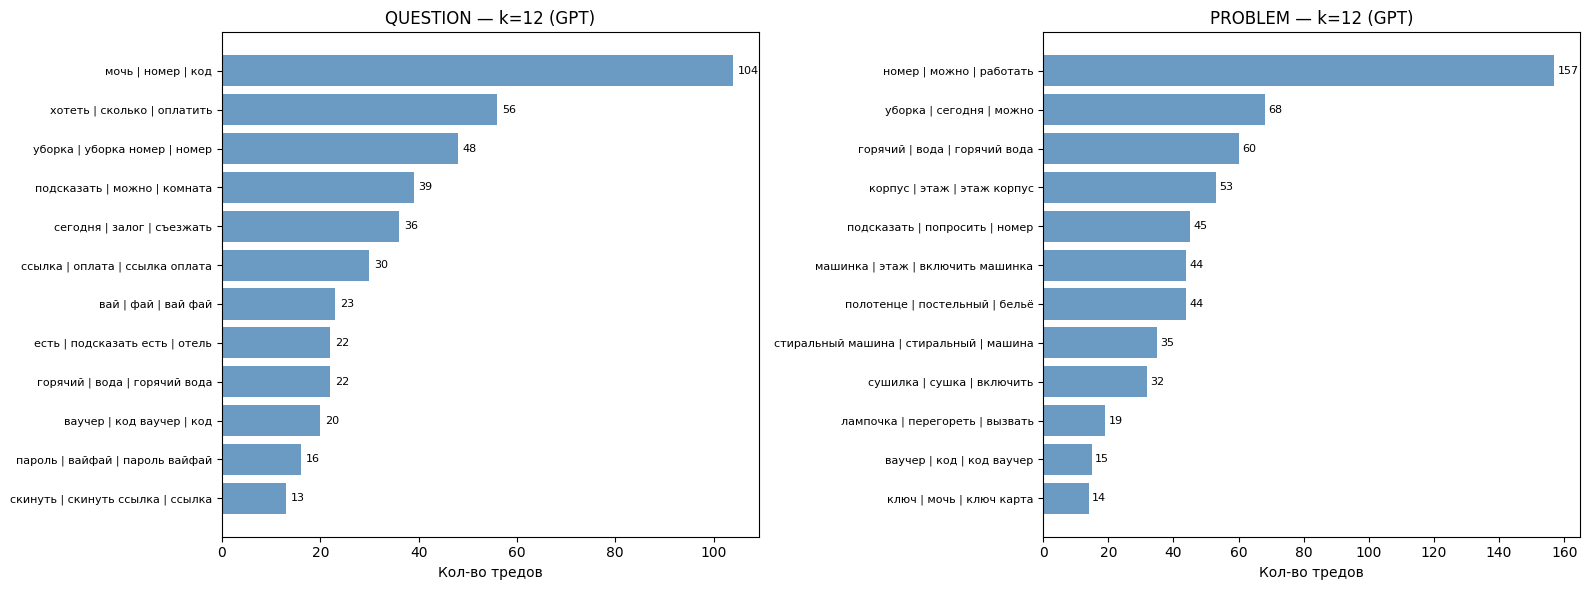

In [13]:
# ── Визуализация: размеры итоговых тем ─────────────────────────────────────────
fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(16, 6))
if len(CATEGORIES) == 1:
    axes = [axes]

for idx, cat in enumerate(CATEGORIES):
    ax = axes[idx]
    pick = final_picks[cat]
    topics = pick['topics']

    # Sort by size descending
    topics_sorted = sorted(topics, key=lambda t: t['size'], reverse=True)
    labels = [' | '.join(t['top_terms'][:3]) for t in topics_sorted]
    sizes = [t['size'] for t in topics_sorted]

    bars = ax.barh(range(len(labels)), sizes, color='steelblue', alpha=0.8)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Кол-во тредов')
    ax.set_title(f'{cat} — k={pick["best_k"]} ({pick["method"]})')

    # Add count labels
    for bar, size in zip(bars, sizes):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                str(size), va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [14]:
# ── Сохранение ────────────────────────────────────────────────────────────────
output = {}
for cat in CATEGORIES:
    pick = final_picks[cat]
    output[cat] = {
        'best_k': pick['best_k'],
        'method': pick['method'],
        'silhouette': round(pick['silhouette'], 4),
        'topics': [
            {
                'id': t['id'],
                'size': int(t['size']),
                'top_terms': list(t['top_terms']),
            }
            for t in pick['topics']
        ],
    }

out_path = Path(PARQUET_PATH).parent / "topic_results.json"
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print(f"💾 Результаты сохранены: {out_path}")
print(json.dumps(output, ensure_ascii=False, indent=2))

💾 Результаты сохранены: topic_results.json
{
  "QUESTION": {
    "best_k": 12,
    "method": "GPT",
    "silhouette": 0.1007,
    "topics": [
      {
        "id": 1,
        "size": 22,
        "top_terms": [
          "есть",
          "подсказать есть",
          "отель",
          "подсказать",
          "ваза"
        ]
      },
      {
        "id": 2,
        "size": 39,
        "top_terms": [
          "подсказать",
          "можно",
          "комната",
          "находиться",
          "зал"
        ]
      },
      {
        "id": 3,
        "size": 30,
        "top_terms": [
          "ссылка",
          "оплата",
          "ссылка оплата",
          "прислать",
          "прислать ссылка"
        ]
      },
      {
        "id": 4,
        "size": 36,
        "top_terms": [
          "сегодня",
          "залог",
          "съезжать",
          "возврат",
          "заявление"
        ]
      },
      {
        "id": 5,
        "size": 23,
        "top_terms": [
         